# Описание проекта

**Описание данных**<br>
**Данные для первой части**<br>
**Файл /datasets/hypothesis.csv**<br>
Hypothesis — краткое описание гипотезы;<br>
Reach — охват пользователей по 10-балльной шкале;<br>
Impact — влияние на пользователей по 10-балльной шкале;<br>
Confidence — уверенность в гипотезе по 10-балльной шкале;<br>
Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.<br>
**Данные для второй части<br>
Файл /datasets/orders.csv**<br>
transactionId — идентификатор заказа;<br>
visitorId — идентификатор пользователя, совершившего заказ;<br>
date — дата, когда был совершён заказ;<br>
revenue — выручка заказа;<br>
group — группа A/B-теста, в которую попал заказ.<br>
**Файл /datasets/visitors.csv**<br>
date — дата;<br>
group — группа A/B-теста;<br>
visitors — количество пользователей в указанную дату в указанной группе A/B-теста<br>
**Описание проекта**<br>
Вы — аналитик крупного интернет-магазина. Вместе с отделом маркетинга вы подготовили список гипотез для увеличения выручки.
Приоритизируйте гипотезы, запустите A/B-тест и проанализируйте результаты. 

**Цель проекта:** Сравнить метрики среднего чека и среднего количества заказов на пользователя между группами

# Предобработка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import scipy.stats as stats

In [2]:
pd.options.display.max_colwidth = 100

In [3]:
#загрузим датафреймы
dfh = pd.read_csv('')
dfo = pd.read_csv('')
dfv = pd.read_csv('')

In [4]:
#посмотрим на таблицу с гипотизами 
dfh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [5]:
#посмотрим на таблицу с заказами
dfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [6]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [7]:
#приведем названия столбцов к правильному стилю написания
dfh.columns = dfh.columns.str.lower()
dfo.columns = dfo.columns.str.lower()

In [8]:
#проверим изменения
dfh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [9]:
#проверим изменения
dfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionid  1197 non-null   int64 
 1   visitorid      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [10]:
#ознакомимся с данными в таблице
#узнаем их соответствие с типом 
print(dfh.head())
print('')
print(dfo.head())
dfv.head()

                                                                                            hypothesis  \
0   Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей   
1                            Запустить собственную службу доставки, что сократит срок доставки заказов   
2  Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средни...   
3  Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар   
4                     Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей   

   reach  impact  confidence  efforts  
0      3      10           8        6  
1      2       5           4       10  
2      8       3           7        3  
3      8       3           3        8  
4      3       1           1        1  

   transactionid   visitorid        date  revenue group
0     3667963787  3312258926  2019-08-15     1650     B
1     2804

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [11]:
#все типы данных правильные кроме даты изменим её
dfo['date'] = pd.to_datetime(dfo['date'], format='%Y-%m-%d')
dfv['date'] = pd.to_datetime(dfv['date'], format='%Y-%m-%d')
#убедимся, что дата теперь имеет тип даты
print(dfo.dtypes)
dfv.dtypes

transactionid             int64
visitorid                 int64
date             datetime64[ns]
revenue                   int64
group                    object
dtype: object


date        datetime64[ns]
group               object
visitors             int64
dtype: object

In [12]:
#найдем полные дубликаты
print(dfh.duplicated().sum())
print(dfo.duplicated().sum())
dfv.duplicated().sum()

0
0


0

Полных дубликатов нету в таблицах, так же по info() видно, что пропусков в этих таблицах нет

In [13]:
#проверим, что гипотезы не совпадают
print(dfh['hypothesis'].nunique())
dfh['hypothesis'].unique()

9


array(['Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей',
       'Запустить собственную службу доставки, что сократит срок доставки заказов',
       'Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа',
       'Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар',
       'Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей',
       'Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов',
       'Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию',
       'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок',
       'Запустить акцию, дающую скидку на товар в день рождения'],
      dtype=object)

In [14]:
#так же убедимся, что оценки для гипотез лежат в диапозоне 1-10 
dfh[['reach','impact','confidence','efforts']].describe()

,reach,impact,confidence,efforts
count,9.000000,9.000000,9.000000,9.000000
mean,4.777778,4.777778,5.555556,4.888889
std,3.153481,3.192874,3.045944,2.803767
min,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,7.000000,5.000000
75%,8.000000,7.000000,8.000000,6.000000
max,10.000000,10.000000,9.000000,10.000000


In [15]:
#убедимся, что индификатор у каждого заказа уникален
dfo['transactionid'].nunique()

1197

In [16]:
#убедимся, что обе группы отмечены верно
dfo['group'].unique()

array(['B', 'A'], dtype=object)

In [17]:
dfv['group'].unique()

array(['A', 'B'], dtype=object)

В предобработке данных были добавлены 3 таблицы с гипотезами, заказами и данными о а/б тесте.<br>
Были изменены типы данных столбцов даты.<br>
Проверены дубликаты и корректность оценок гипотез.

# Часть 1. Приоритизация гипотез.

Даны 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort. <br>
 <br>
Применим фреймворк ICE для приоритизации гипотез. Отсортируем их по убыванию приоритета.<br>
Применим фреймворк RICE для приоритизации гипотез. Отсортируем их по убыванию приоритета.<br>
Укажем, как изменилась приоритизация гипотез при применении RICE вместо ICE.

In [18]:
#применим фреймворк ICE для приоритизации
dfh['ice'] =  round(dfh['impact'] * dfh['confidence'] / dfh['efforts'], 2)
dfh.sort_values('ice', ascending = False)

,hypothesis,reach,impact,confidence,efforts,ice
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конве...",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средни...",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


In [19]:
#применим фреймворк RICE для приоритизации
dfh['rice'] = dfh['reach'] * dfh['impact'] * dfh['confidence'] / dfh['efforts']
dfh.sort_values('rice', ascending = False)

,hypothesis,reach,impact,confidence,efforts,ice,rice
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средни...",8,3,7,3,7.00,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конве...",5,3,8,3,8.00,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.0


Приоритеты гипотез методом rice изменились в сравнении с методом ice.<br>
гипотеза с первого места по значимости методом ice упала на 5 место по методу rice и наоборот с 5 места поднялась на 2.<br>
Так случилось потому, что в методе Rice задействована оценка reach, которая позволяет еще и оценить охватываемость пользователей. Логично, чем больше пользователей охватывает гипотеза, тем она более значима для бизнеса. <br>
Гипотезы, лидирующие в методе ice, узконаправленные и не охватывают большую долю пользователей. Поэтому в методе rice они упали

# Часть 2. Анализ A/B-теста
Вы провели A/B-тест и получили результаты, которые описаны в dfo dfv

## Построим график кумулятивной выручки по группам. Сделаем выводы и предположения.

In [20]:
# создаем массив уникальных пар значений дат и групп теста
df_group = dfo[['date','group']].drop_duplicates()

In [21]:
df_group.head(10)

,date,group
0,2019-08-15,B
2,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A
66,2019-08-01,B
85,2019-08-22,B
86,2019-08-22,A
124,2019-08-17,A
125,2019-08-17,B


In [22]:
#Агрегируем значения
orders_aggregated = df_group.apply(lambda x: dfo[np.logical_and(dfo['date'] <= x['date'], dfo['group'] == x['group'])]\
.agg({'date' : 'max', 'group' : 'max', 'transactionid' : 'nunique', 'visitorid' : 'nunique', 'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

In [23]:
orders_aggregated.head(10)

,date,group,transactionid,visitorid,revenue
55,2019-08-01,A,24,20,148579
66,2019-08-01,B,21,20,101217
175,2019-08-02,A,44,38,242401
173,2019-08-02,B,45,43,266748
291,2019-08-03,A,68,62,354874
310,2019-08-03,B,61,59,380996
499,2019-08-04,A,84,77,425699
498,2019-08-04,B,78,75,489567
698,2019-08-05,A,109,100,549917
699,2019-08-05,B,101,98,581995


In [24]:
dfv.head(10)

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


In [25]:
#Аналогично получим агрегированные кумулятивные по дням данные о посетителях интернет-магазина
visitors_aggregated = df_group.apply(lambda x: dfv[np.logical_and(dfv['date'] <= x['date'], dfv['group'] == x['group'])]\
.agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), axis=1).sort_values(by=['date','group'])
visitors_aggregated.head(10)

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845
310,2019-08-03,B,1803
499,2019-08-04,A,2562
498,2019-08-04,B,2573
698,2019-08-05,A,3318
699,2019-08-05,B,3280


In [26]:
#Объединим обе таблицы в одну с понятными названиями столбцов
cumulative_df = orders_aggregated.merge(visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulative_df.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

print(cumulative_df.head(10))

        date group  orders  buyers  revenue  visitors
0 2019-08-01     A      24      20   148579       719
1 2019-08-01     B      21      20   101217       713
2 2019-08-02     A      44      38   242401      1338
3 2019-08-02     B      45      43   266748      1294
4 2019-08-03     A      68      62   354874      1845
5 2019-08-03     B      61      59   380996      1803
6 2019-08-04     A      84      77   425699      2562
7 2019-08-04     B      78      75   489567      2573
8 2019-08-05     A     109     100   549917      3318
9 2019-08-05     B     101      98   581995      3280


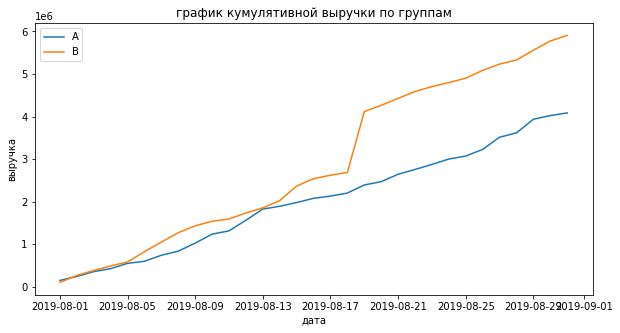

In [50]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_a = cumulative_df[cumulative_df['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_b = cumulative_df[cumulative_df['group']=='B'][['date','revenue', 'orders']]
plt.figure(figsize=(10, 5))
plt.xlabel('дата')
plt.ylabel('выручка')
# Строим график выручки группы А
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'], label='B')
plt.title('график кумулятивной выручки по группам')
plt.legend(); 

Продажи группы А с 19.08 резко увеличились, возможно есть аномальное значение которое повлияло на это. Выводы пока делать рано

## Построим график кумулятивного среднего чека по группам. Сделаем выводы и предположения.

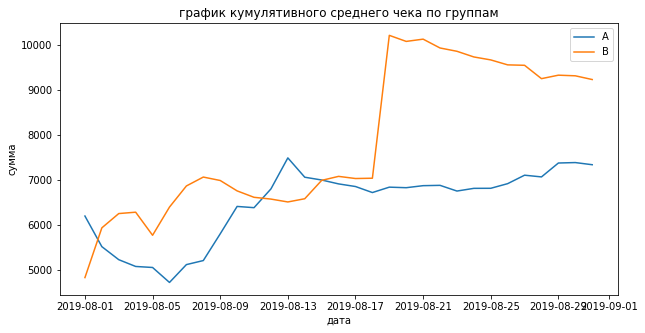

In [51]:
#Построим графики среднего чека по группам — разделим кумулятивную выручку на кумулятивное число заказов
plt.figure(figsize=(10, 5))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue']/cumulative_revenue_a['orders'], label='A')
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue']/cumulative_revenue_b['orders'], label='B')
plt.xlabel('дата')
plt.ylabel('сумма')
plt.title('график кумулятивного среднего чека по группам')
plt.legend();

Так же средний чек вырос как и вырукчка примерно 19.08, но потом падает. До 19.08 графики имеют 3 точки пересечения. Трудно делать какие-либо выводы.

## Построим график относительного изменения кумулятивного среднего чека группы B к группе A. Сделаем выводы и предположения.

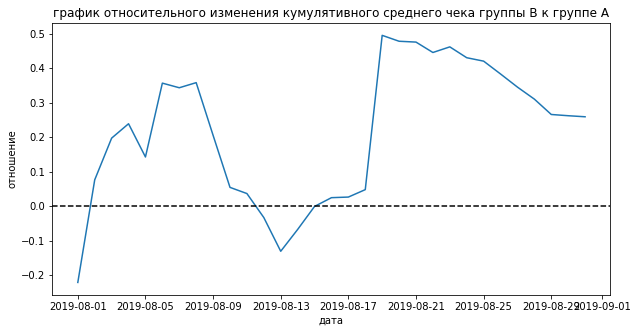

In [52]:
# собираем данные в одном датафрейме
merged_cumulative_revenue = cumulative_revenue_a.merge(cumulative_revenue_b, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])
plt.figure(figsize=(10, 5))
# cтроим отношение средних чеков
plt.plot(merged_cumulative_revenue['date'], (merged_cumulative_revenue['revenueB']/merged_cumulative_revenue['ordersB'])/(merged_cumulative_revenue['revenueA']/merged_cumulative_revenue['ordersA'])-1)
plt.title('график относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xlabel('дата')
plt.ylabel('отношение')
# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--'); 

Видим крупные скачки, явно тут есть аномальные значения

## Построим график кумулятивного среднего количества заказов на посетителя по группам. Сделаем выводы и предположения.

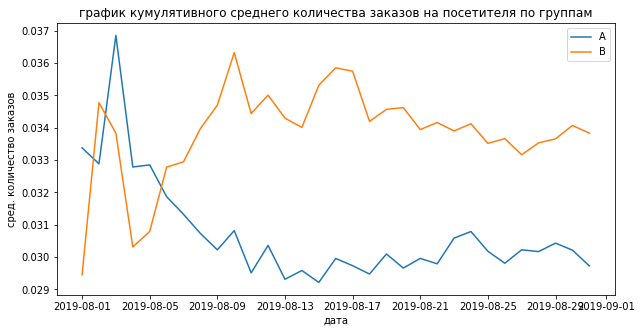

In [53]:
# считаем среднее количество заказов на посетителя
cumulative_df['conversion'] = cumulative_df['orders']/cumulative_df['visitors']

# отделяем данные по группе A
cumulative_a = cumulative_df[cumulative_df['group']=='A']

# отделяем данные по группе B
cumulative_b = cumulative_df[cumulative_df['group']=='B']

# строим графики
plt.figure(figsize=(10, 5))
plt.plot(cumulative_a['date'], cumulative_a['conversion'], label='A')
plt.plot(cumulative_b['date'], cumulative_b['conversion'], label='B')
plt.xlabel('дата')
plt.ylabel('сред. количество заказов')
plt.title('график кумулятивного среднего количества заказов на посетителя по группам')
plt.legend();

У группы А заказов на пользователя было изначально больше, но потом в группе В, стало больше заказов на одного пользователя.<br>значения зафиксировались, хоть и с шумами, но идут парралельно друг другу

## Построим график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

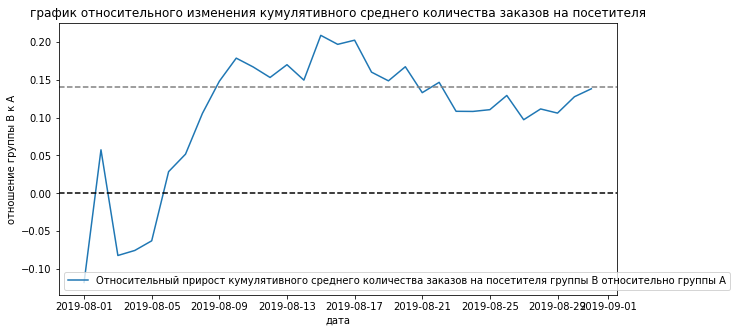

In [54]:
merged_cumulative_conversions = cumulative_a[['date','conversion']].merge(cumulative_b[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])
plt.figure(figsize=(10, 5))
plt.plot(merged_cumulative_conversions['date'], merged_cumulative_conversions['conversionB']/merged_cumulative_conversions['conversionA']-1, label="Относительный прирост кумулятивного среднего количества заказов на посетителя группы B относительно группы A")
plt.legend()
plt.xlabel('дата')
plt.ylabel('отношение группы В к А')
plt.title('график относительного изменения кумулятивного среднего количества заказов на посетителя')
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.14, color='grey', linestyle='--');

Отношение среднего количества заказов на посетителя ещё не установилось.<br>
До 19.08 трудно анализировать отношение среднего количества заказов на посетителя группы В к группе А, но после<br>
этого числа резко группа В вырывается вперёд.

## Построим точечный график количества заказов по пользователям

In [32]:
dfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionid  1197 non-null   int64         
 1   visitorid      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


In [33]:
orders_users = (
    dfo.groupby('visitorid', as_index=False)
    .agg({'transactionid': 'nunique'})
)

orders_users.columns = ['userid', 'orders']

print(orders_users.sort_values(by='orders', ascending=False).head(10))

          userid  orders
1023  4256040402      11
591   2458001652      11
569   2378935119       9
487   2038680547       8
44     199603092       5
744   3062433592       5
55     237748145       5
917   3803269165       5
299   1230306981       5
897   3717692402       5


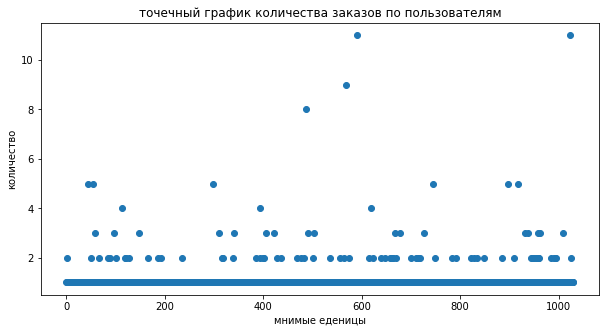

In [55]:
#Построим точечную диаграмму числа заказов на одного пользователя
x_values_ord = pd.Series(range(0,len(orders_users)))
plt.figure(figsize=(10, 5))
plt.xlabel('мнимые еденицы')
plt.ylabel('количество')
plt.title('точечный график количества заказов по пользователям')
plt.scatter(x_values_ord, orders_users['orders']);

По графику видим, что в данных имеются выбросы

## Посчитаем 95-й и 99-й перцентили количества заказов на пользователя

In [35]:
print(np.percentile(orders_users['orders'], [95, 99]))

[2. 4.]


Не более 5% пользователей оформляли больше чем 2 заказа. И 1% пользователей заказывали более 4 раз.<br> 
Выбререм 4 заказа на одного пользователя за верхнюю границу числа заказов, и отсеять аномальных пользователей по ней.

## Построим точечный график стоимостей заказов

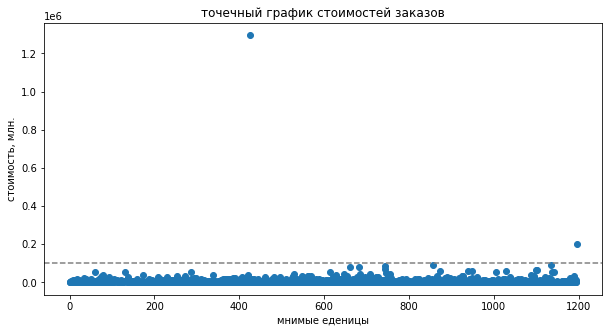

In [56]:
x_values_rev = pd.Series(range(0,len(dfo['revenue'])))
plt.figure(figsize=(10, 5))
plt.xlabel('мнимые еденицы')
plt.ylabel('стоимость, млн.')
plt.title('точечный график стоимостей заказов')
plt.scatter(x_values_rev, dfo['revenue'])
plt.axhline(y=100000, color='grey', linestyle='--');

Видим два ярко выделяющихся аномальных заказа. Так же зададим масштаб для более явного понимания истинных значений

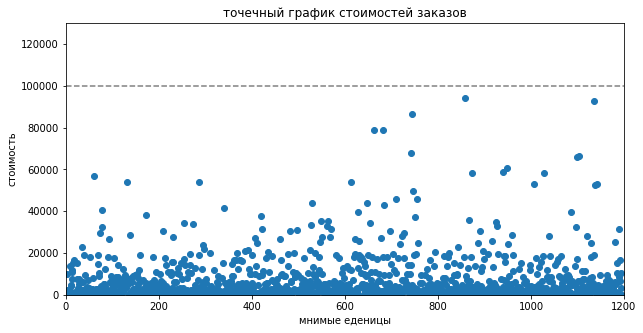

In [57]:
x_values_rev = pd.Series(range(0,len(dfo['revenue'])))
plt.figure(figsize=(10, 5))
plt.xlabel('мнимые еденицы')
plt.ylabel('стоимость')
plt.title('точечный график стоимостей заказов')
plt.scatter(x_values_rev, dfo['revenue'])
plt.axis([0, 1200, 0, 130000])
plt.axhline(y=100000, color='grey', linestyle='--');

## Посчитаем 95-й и 99-й перцентили стоимости заказов

In [38]:
print(np.percentile(dfo['revenue'], [95, 99])) 

[28000.  58233.2]


Стоимость более 28руб имеют 5% заказов. 1% заказов имеют стоимость в 58233 руб. Зададим верхнюю планку в 58 тыс.

## Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным

Сформулируем гипотезы. Нулевая: различий в среднем количестве заказов между группами нет. Альтернативная: различия в среднем между группами есть.
Начнём с подготовки данных

In [39]:
dfv.head(2)

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619


In [40]:
dfo.head(2)

,transactionid,visitorid,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B


In [41]:
visitors_a_daily = dfv[dfv['group'] == 'A'][['date', 'visitors']]
visitors_a_daily.columns = ['date', 'visitors_date_a']

visitors_a_cummulative = visitors_a_daily.apply(
    lambda x: visitors_a_daily[visitors_a_daily['date'] <= x['date']].agg(
        {'date': 'max', 'visitors_date_a': 'sum'}
    ),
    axis=1,
)
visitors_a_cummulative.columns = ['date', 'visitors_cummulative_a']

visitors_b_daily = dfv[dfv['group'] == 'B'][['date', 'visitors']]
visitors_b_daily.columns = ['date', 'visitors_date_b']

visitors_b_cummulative = visitors_b_daily.apply(
    lambda x: visitors_b_daily[visitors_b_daily['date'] <= x['date']].agg(
        {'date': 'max', 'visitors_date_b': 'sum'}
    ),
    axis=1,
)
visitors_b_cummulative.columns = ['date', 'visitors_cummulative_b']

orders_a_daily = (
    dfo[dfo['group'] == 'A'][['date', 'transactionid', 'visitorid', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionid': pd.Series.nunique, 'revenue': 'sum'})
)
orders_a_daily.columns = ['date', 'orders_date_a', 'revenue_date_a']

orders_a_cummulative = orders_a_daily.apply(
    lambda x: orders_a_daily[orders_a_daily['date'] <= x['date']].agg(
        {'date': 'max', 'orders_date_a': 'sum', 'revenue_date_a': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
orders_a_cummulative.columns = [
    'date',
    'orders_cummulative_a',
    'revenue_cummulative_a',
]

orders_b_daily = (
    dfo[dfo['group'] == 'B'][['date', 'transactionid', 'visitorid', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionid': pd.Series.nunique, 'revenue': 'sum'})
)
orders_b_daily.columns = ['date', 'orders_date_b', 'revenue_date_b']

orders_b_cummulative = orders_b_daily.apply(
    lambda x: orders_b_daily[orders_b_daily['date'] <= x['date']].agg(
        {'date': 'max', 'orders_date_b': 'sum', 'revenue_date_b': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
orders_b_cummulative.columns = [
    'date',
    'orders_cummulative_b',
    'revenue_cummulative_b',
]

data = (
    orders_a_daily.merge(
        orders_b_daily, left_on='date', right_on='date', how='left'
    )
    .merge(orders_a_cummulative, left_on='date', right_on='date', how='left')
    .merge(orders_b_cummulative, left_on='date', right_on='date', how='left')
    .merge(visitors_a_daily, left_on='date', right_on='date', how='left')
    .merge(visitors_b_daily, left_on='date', right_on='date', how='left')
    .merge(visitors_a_cummulative, left_on='date', right_on='date', how='left')
    .merge(visitors_b_cummulative, left_on='date', right_on='date', how='left')
)

print(data.head(5))

        date  orders_date_a  revenue_date_a  orders_date_b  revenue_date_b  \
0 2019-08-01             24          148579             21          101217   
1 2019-08-02             20           93822             24          165531   
2 2019-08-03             24          112473             16          114248   
3 2019-08-04             16           70825             17          108571   
4 2019-08-05             25          124218             23           92428   

   orders_cummulative_a  revenue_cummulative_a  orders_cummulative_b  \
0                    24                 148579                    21   
1                    44                 242401                    45   
2                    68                 354874                    61   
3                    84                 425699                    78   
4                   109                 549917                   101   

   revenue_cummulative_b  visitors_date_a  visitors_date_b  \
0                 101217            

Напомним названия столбцов данных:<br>
**date** — дата;<br>
**orders_date_a** — количество заказов в выбранную дату в группе A;<br>
**revenue_date_a** — суммарная выручка в выбранную дату в группе A;<br>
**orders_date_b** — количество заказов в выбранную дату в группе B;<br>
**revenue_date_b** — суммарная выручка в выбранную дату в группе B;<br>
**orders_cummulative_a** — суммарное число заказов до выбранной даты включительно в группе A;<br>
**revenue_cummulative_a** — суммарная выручка до выбранной даты включительно в группе A;<br>
**orders_cummulative_b** — суммарное количество заказов до выбранной даты включительно в группе B;<br>
**revenue_cummulative_b** — суммарная выручка до выбранной даты включительно в группе B;<br>
**visitors_date_a** — количество пользователей в выбранную дату в группе A;<br>
**visitors_date_b** — количество пользователей в выбранную дату в группе B;<br>
**visitors_cummulative_a** — количество пользователей до выбранной даты включительно в группе A;<br>
**visitors_cummulative_b** — количество пользователей до выбранной даты включительно в группе B.<br>

Посчитаем статистическую значимость различия в среднем количестве заказов между группами.<br>
Создадим переменные orders_users_a и orders_users_b со столбцами ['userid', 'orders']. В них для пользователей, которые заказывали хотя бы 1 раз, укажем число совершённых заказов. 

In [42]:
orders_users_a = (
    dfo[dfo['group'] == 'A']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
orders_users_a.columns = ['userid', 'orders']

orders_users_b = (
    dfo[dfo['group'] == 'B']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
orders_users_b.columns = ['userid', 'orders']

In [43]:
#Выведем относительный прирост среднего числа заказов группы B:
#среднее число заказов группы B / среднее число заказов группы A - 1.  Округлим до трёх знаков после запятой.
sample_a = pd.concat(
    [
        orders_users_a['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitors_date_a'].sum() - len(orders_users_a['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sample_b = pd.concat(
    [
        orders_users_b['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitors_date_b'].sum() - len(orders_users_b['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

print('p-value = ',"{0:.3f}".format(stats.mannwhitneyu(sample_a, sample_b)[1]))

print("{0:.3f}".format(sample_b.mean() / sample_a.mean() - 1))

p-value =  0.017
0.138


По "сырым" данным p-value меньше 0.05, значит мы отвераем нулевую гипотезу о равенстве двух групп.
группа В выигрывает на 13.8% группу А

## Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным

In [44]:
#Чтобы рассчитать статистическую значимость различий в среднем чеке
#передадим критерию mannwhitneyu() данные о выручке с заказов
print('p-value =','{0:.3f}'.format(stats.mannwhitneyu(dfo[dfo['group']=='A']['revenue'], dfo[dfo['group']=='B']['revenue'])[1]))
#А ещё найдём относительные различия в среднем чеке между группами
print('{0:.3f}'.format(dfo[dfo['group']=='B']['revenue'].mean()/dfo[dfo['group']=='A']['revenue'].mean()-1)) 

p-value = 0.729
0.259


P-value больше 0.05. Значит, причин отвергать нулевую гипотезу и считать, что в среднем чеке есть различия, нет.<br> средний чек группы B больше среднего чека группы A.

## Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Верхней границей среднего количества заказов на пользователя мы решили брать - 4<br>
А верхней границей средней суммы заказа решили взять - 58000

In [45]:
#Узнаем, сколько всего аномальных пользователей атрибутом shape
users_many_orders = pd.concat(
    [
        orders_users_a[orders_users_a['orders'] > 4]['userid'],
        orders_users_b[orders_users_b['orders'] > 4]['userid'],
    ],
    axis=0,
)
users_orders = dfo[dfo['revenue'] > 58000]['visitorid']
abnormal_users = (
    pd.concat([users_many_orders, users_orders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print(abnormal_users.head(5))
print(abnormal_users.shape[0])

1099     148427295
949      887908475
744      888512513
1103    1164614297
1136    1307669133
dtype: int64
15


15 пользователей являются аномальными

In [46]:
sample_a_filt = pd.concat(
    [
        orders_users_a[
            np.logical_not(orders_users_a['userid'].isin(abnormal_users))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitors_date_a'].sum() - len(orders_users_a['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sample_b_filt = pd.concat(
    [
        orders_users_b[
            np.logical_not(orders_users_b['userid'].isin(abnormal_users))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitors_date_b'].sum() - len(orders_users_b['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

Применим статистический критерий Манна-Уитни к полученным выборкам

In [47]:
print('p-value =''{0:.3f}'.format(stats.mannwhitneyu(sample_a_filt, sample_b_filt)[1]))
print('{0:.3f}'.format(sample_b_filt.mean()/sample_a_filt.mean()-1)) 

p-value =0.014
0.153


По фильтрованным данным, результаты почти те же самые. Отвергаем нулевую гипотезу и принимаем, что количество среднее количество заказов увеличилось

## Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным

In [48]:
print(
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            dfo[
                np.logical_and(
                    dfo['group'] == 'A',
                    np.logical_not(dfo['visitorid'].isin(abnormal_users)),
                )
            ]['revenue'],
            dfo[
                np.logical_and(
                    dfo['group'] == 'B',
                    np.logical_not(dfo['visitorid'].isin(abnormal_users)),
                )
            ]['revenue'],
        )[1]
    )
)

print(
    "{0:.3f}".format(
        dfo[
            np.logical_and(
                dfo['group'] == 'B',
                np.logical_not(dfo['visitorid'].isin(abnormal_users)),
            )
        ]['revenue'].mean()
        / dfo[
            np.logical_and(
                dfo['group'] == 'A',
                np.logical_not(dfo['visitorid'].isin(abnormal_users)),
            )
        ]['revenue'].mean()
        - 1
    )
)

0.851
-0.006


p-value увеличилось немного в сравнении с 'сырыми' данными, и мы так же не можем отвергнуть нулевую гипотезу, что сегменты равны в среднем чеке. Разницы между средними чеками менее 1%

## Решение продолжать ли тест

Решение остановить тест и зафиксировать победу группы В, так как видим достаточные основания, что пользователи из группы В стали больше заказывать, при этом средний чек остался тем же. Но больше заказов при том же среднем чеке уже дает бОльшую прибыль.

Графики кумулятивного среднего количества заказов на посетителя по группам и график отношения групп показывают положительный результат для группы В

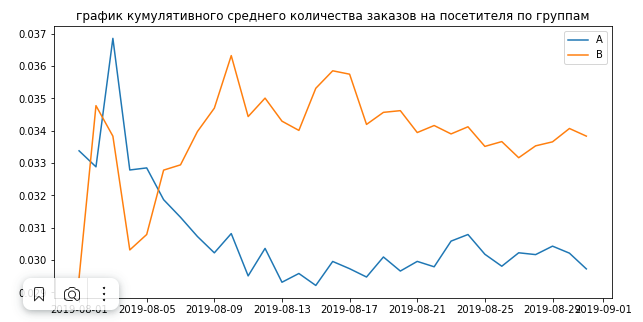

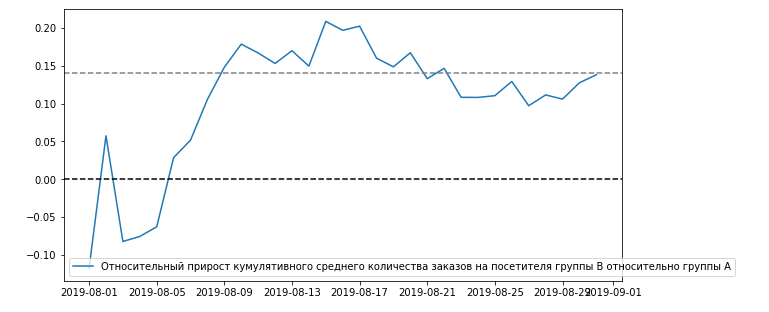

Так же тест на статистическую значимость различий в среднем количестве заказов на посетителя между группами указывает на положительный результат. А тест на статистическую значимость различий в среднем чеке подтверждает то, что средний чек остался преждним.